In [2]:
import numpy as np
import pandas as pd
from skimage.color import rgb2gray
from PIL import Image
from tifffile import imread
import tifffile
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.morphology import disk, binary_dilation
from io import StringIO
import imageio
import os

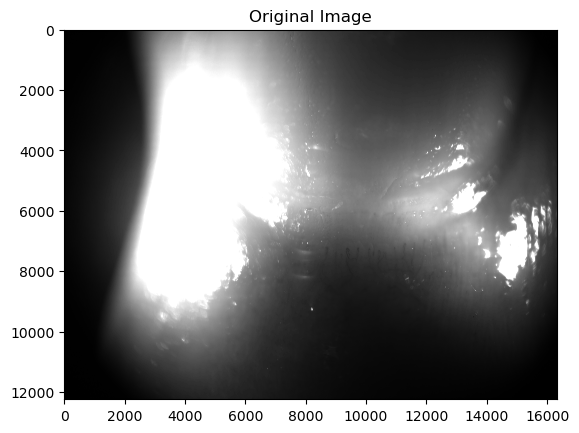

In [2]:
image_20 = imread("../_images/C2-20250829_001448.tif")
plt.imshow(image_20, cmap='gray')
plt.title("Original Image")
plt.show()

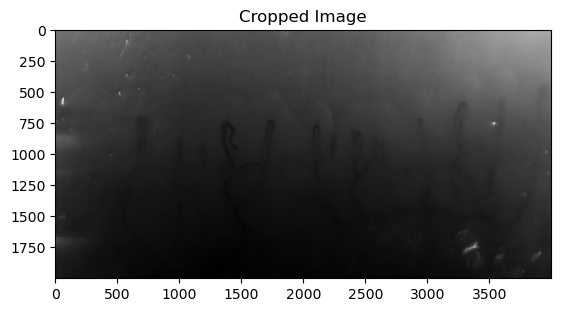

In [3]:
cropped_img = image_20[6500:8500, 8000:12000] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

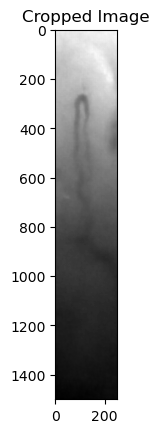

In [4]:
cropped_img = image_20[7000:8500, 10000:10250] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

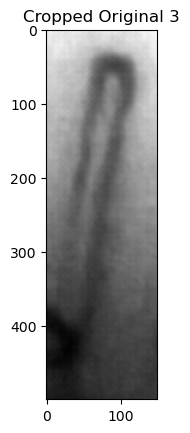

In [22]:
cropped_img_1 = image_20[7200:7700, 9650:9800] 
plt.imshow(cropped_img_1, cmap='gray')
plt.title("Cropped Original 3")
plt.show()

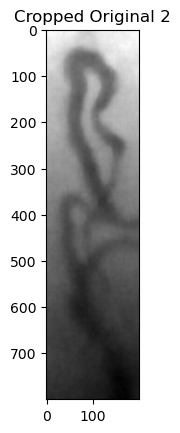

In [15]:
cropped_img_1 = image_20[7200:8000, 9300:9500] 
plt.imshow(cropped_img_1, cmap='gray')
plt.title("Cropped Original 2")
plt.show()

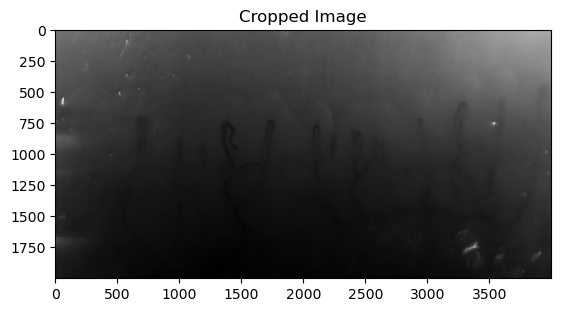

In [16]:
cropped_img = image_20[6500:8500, 8000:12000] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

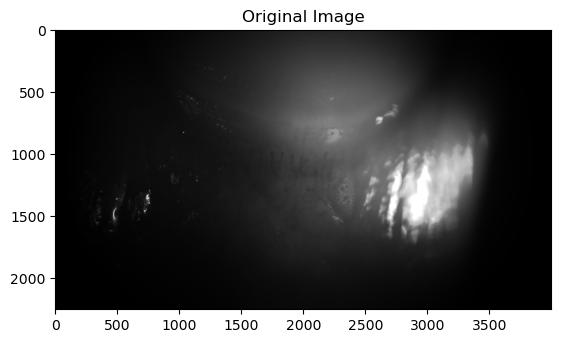

In [2]:
image_raw = imread("../_images/RAW_median/20250620_103932_299709_p[RealtimeDefault0]_req[6973]_ChiNum[6972]_Mode[7]_batch[0]_MCTFE[0]_[out]_port[50]_w[4000]_h[2252]_stride[5040]_scanline[2252]_FILTERED.tiff")
plt.imshow(image_raw, cmap='gray')
plt.title("Original Image")
plt.show()

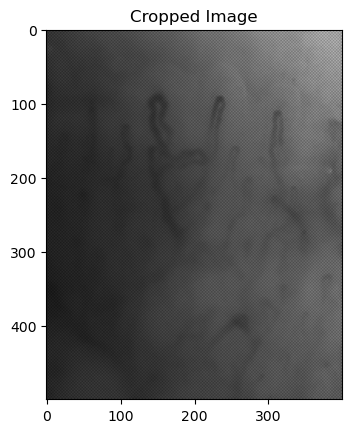

In [20]:
cropped_img = image_raw[900:1400, 1600:2000] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

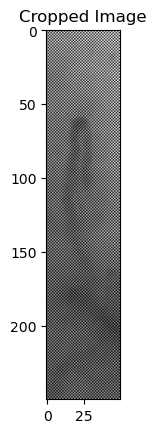

In [29]:
cropped_img = image_raw[950:1200, 1890:1940] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

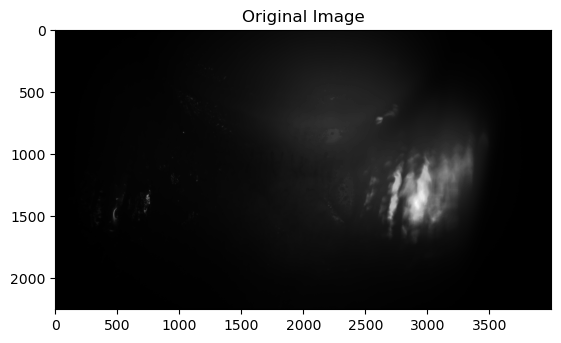

In [40]:
image_raw_2 = imread("../_images/RAW_debayered/20250620_contrast.tif")
plt.imshow(image_raw_2, cmap='gray')
plt.title("Original Image")
plt.show()

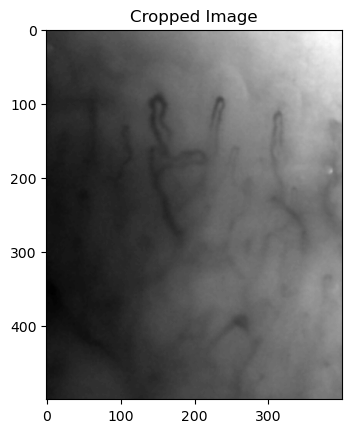

In [41]:
cropped_img = image_raw_2[900:1400, 1600:2000] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

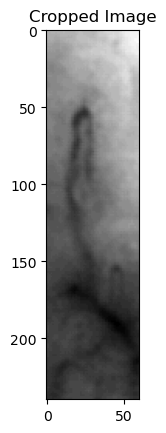

In [71]:
cropped_img = image_raw_2[960:1200, 1890:1950] 
plt.imshow(cropped_img, cmap='gray')
plt.title("Cropped Image")
plt.show()

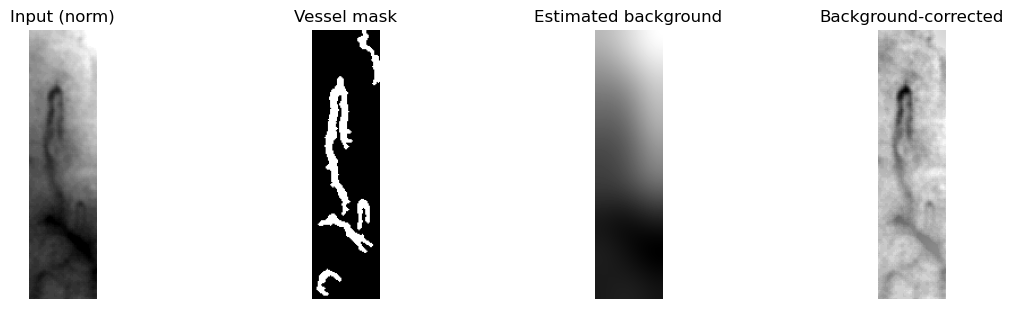

In [90]:
from skimage.filters import threshold_otsu, meijering
from skimage.morphology import remove_small_objects, remove_small_holes, disk, binary_dilation
from skimage.restoration import inpaint
from scipy.ndimage import gaussian_filter

img_crop = cropped_img.astype(np.float32)
p1, p99 = np.percentile(img_crop, (1, 99))
img_n = np.clip((img_crop - p1) / (p99 - p1 + 1e-8), 0, 1)

# 1) Vessel mask (dark ridges)
sigmas = np.geomspace(1, 2, 2)  
resp = meijering(img_n, sigmas=sigmas, black_ridges=True)
resp = (resp - resp.min()) / (resp.max() - resp.min() + 1e-8)
BW = resp > threshold_otsu(resp)

# Cleanup & give some margin around vessels
BW = remove_small_objects(BW, min_size=100)
BW = remove_small_holes(BW, area_threshold=200)
BW = binary_dilation(BW, disk(1))          

# 2) Inpaint vessel regions
mask = BW.astype(bool)
img_inp = inpaint.inpaint_biharmonic(img_n, mask, channel_axis=None)

# 3) Low-pass the inpainted image to get background (use scale >> vessel width)
bg = gaussian_filter(img_inp, sigma=15)    

# 4) Background correction (keep range sane)
img_corr = np.clip(img_n - bg + bg.mean(), 0, 1)

fig, ax = plt.subplots(1,4, figsize=(14,3.5))
ax[0].imshow(img_n, cmap='gray'); ax[0].set_title('Input (norm)'); ax[0].axis('off')
ax[1].imshow(BW, cmap='gray');    ax[1].set_title('Vessel mask'); ax[1].axis('off')
ax[2].imshow(bg, cmap='gray');    ax[2].set_title('Estimated background'); ax[2].axis('off')
ax[3].imshow(img_corr, cmap='gray'); ax[3].set_title('Background-corrected'); ax[3].axis('off')
plt.show()

In [91]:
import imageio.v3 as iio
OUTPUT_FOLDER = "." # Saves in the current working directory
BACKGROUND_FILENAME = "estimated_background.tiff"
output_path = os.path.join(OUTPUT_FOLDER, BACKGROUND_FILENAME)

iio.imwrite(output_path, bg.astype(np.float32))
print(f"\nSuccessfully saved background image to: {output_path}")


Successfully saved background image to: ./estimated_background.tiff


Sampling 30 lines from y=65 to y=75...
Sampling complete.

--- Analysis Results (Original 16-bit scale) ---
Background Min Intensity: 145.865821
Background Mean Intensity: 147.061181
Capillary Min Intensity: 136.000000
Capillary Mean Intensity: 141.553284

Saved mean profile stats to "intensity_profile_mean_PYTHON.csv"


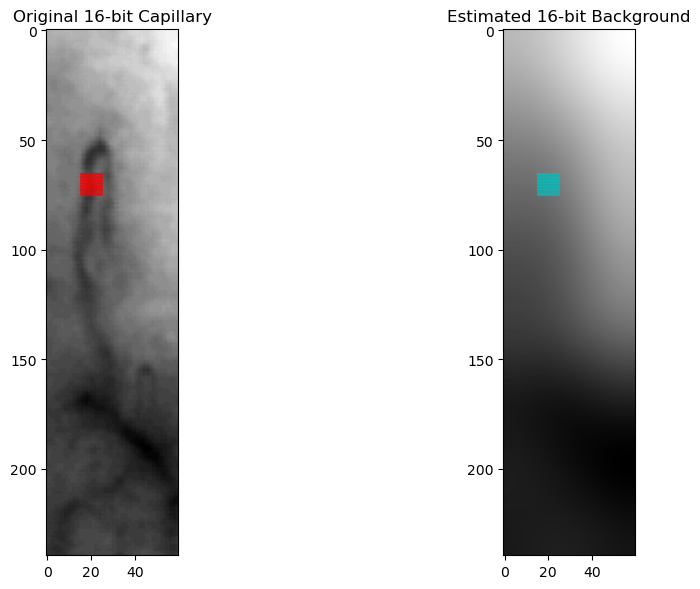

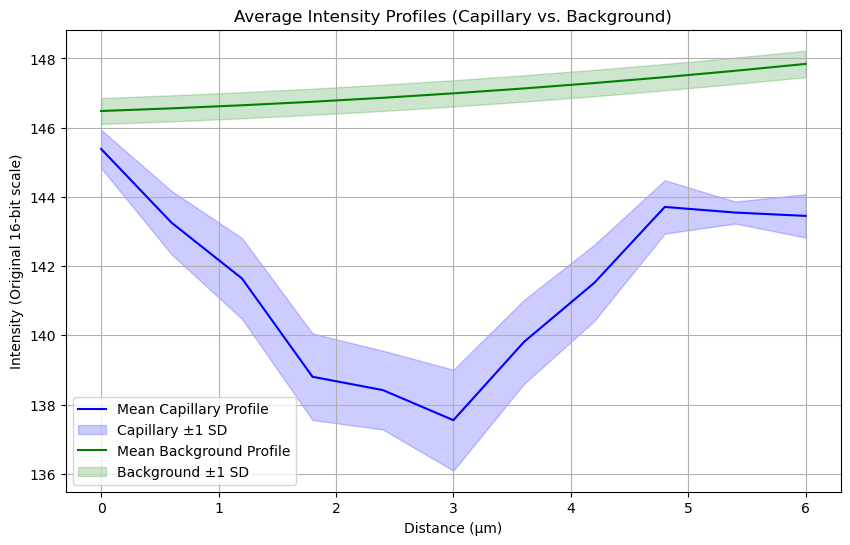

In [ ]:
from skimage.measure import profile_line
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Sampling Parameters (from your MATLAB script) ---
x_start = 15
x_end = 25
num_lines = 30
y_min = 65
y_max = 75

y_coords = np.linspace(y_min, y_max, num_lines)
bg_unnormalized = (bg * (p99 - p1 + 1e-8)) + p1

profiles_bg = []  # To store background profiles
profiles_cap = [] # To store capillary profiles

print(f"Sampling {num_lines} lines from y={y_min} to y={y_max}...")

for y in y_coords:
    # Define start and end points for the line
    start_point = (y, x_start) # (row, col)
    end_point = (y, x_end)   # (row, col)
    
    # Get profile from the UN-NORMALIZED background
    p_bg = profile_line(bg_unnormalized, start_point, end_point, mode='constant')
    profiles_bg.append(p_bg)
    
    # Get profile from the ORIGINAL 16-BIT capillary image ('img_crop')
    p_cap = profile_line(img_crop, start_point, end_point, mode='constant')
    profiles_cap.append(p_cap)

# Convert lists of profiles into 2D NumPy arrays
profiles_bg = np.array(profiles_bg)
profiles_cap = np.array(profiles_cap)

print("Sampling complete.")

# --- 3. Analyze the Profiles ---
# Both images are now on the SAME 16-bit unnormalized scale

# Background stats
min_intensity_bg = np.min(profiles_bg)
mean_intensity_bg = np.mean(profiles_bg)
mean_profile_bg = np.mean(profiles_bg, axis=0)
std_profile_bg = np.std(profiles_bg, axis=0)

# Capillary stats
min_intensity_cap = np.min(profiles_cap)
mean_intensity_cap = np.mean(profiles_cap)
mean_profile_cap = np.mean(profiles_cap, axis=0)
std_profile_cap = np.std(profiles_cap, axis=0)

# --- 4. Output and Save Results ---
print("\n--- Analysis Results (Original 16-bit scale) ---")
print(f"Background Min Intensity: {min_intensity_bg:.6f}")
print(f"Background Mean Intensity: {mean_intensity_bg:.6f}")
print(f"Capillary Min Intensity: {min_intensity_cap:.6f}")
print(f"Capillary Mean Intensity: {mean_intensity_cap:.6f}")

# --- 5. Create Distance Axis and Save to CSV (like MATLAB) ---
pix_um = 0.6  # Your pixel-to-micron scale
N = profiles_bg.shape[1] # Number of sample points in the profile
dist_px = np.arange(N)
dist_um = dist_px * pix_um

# Create a summary DataFrame
T_mean = pd.DataFrame({
    'Sample': np.arange(N),
    'Dist_px': dist_px,
    'Dist_um': dist_um,
    'MeanIntensity_Cap': mean_profile_cap,
    'StdIntensity_Cap': std_profile_cap,
    'MeanIntensity_Bg': mean_profile_bg,
    'StdIntensity_Bg': std_profile_bg
})

T_mean.to_csv('intensity_profile_mean_PYTHON.csv', index=False)
print(f'\nSaved mean profile stats to "intensity_profile_mean_PYTHON.csv"')

# --- 6. Plot the Images with Sampling Lines ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Original 16-bit Capillary Image
ax[0].imshow(img_crop, cmap='gray')
ax[0].set_title('Original 16-bit Capillary')
ax[0].axis('on')
# Draw the sampling lines
for y in y_coords:
    ax[0].plot([x_start, x_end], [y, y], 'r-', linewidth=0.5)

# Plot 2: Estimated 16-bit Background Image
ax[1].imshow(bg_unnormalized, cmap='gray')
ax[1].set_title('Estimated 16-bit Background')
ax[1].axis('on')
# Draw the sampling lines
for y in y_coords:
    ax[1].plot([x_start, x_end], [y, y], 'c-', linewidth=0.5)

plt.tight_layout()
plt.show()


# --- 7. Plot the Mean Profiles ---
plt.figure(figsize=(10, 6))
plt.grid(True)
plt.plot(dist_um, mean_profile_cap, 'b-', label='Mean Capillary Profile')
plt.fill_between(dist_um, mean_profile_cap - std_profile_cap, 
                 mean_profile_cap + std_profile_cap, 
                 color='blue', alpha=0.2, label='Capillary ±1 SD')

plt.plot(dist_um, mean_profile_bg, 'g-', label='Mean Background Profile')
plt.fill_between(dist_um, mean_profile_bg - std_profile_bg, 
                 mean_profile_bg + std_profile_bg, 
                 color='green', alpha=0.2, label='Background ±1 SD')

plt.xlabel('Distance (µm)')
plt.ylabel('Intensity (Original 16-bit scale)')
plt.title('Average Intensity Profiles (Capillary vs. Background)')
plt.legend()
plt.show()



## 12 MP Image

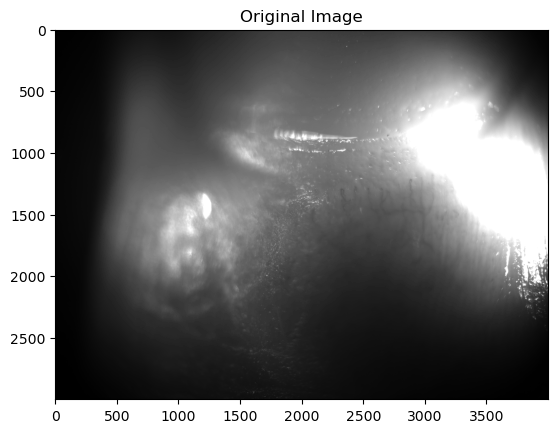

In [95]:
image_12 = imread("../_images/10-31-2025/20251031_045917.tif")
plt.imshow(image_12, cmap='gray')
plt.title("Original Image")
plt.show()

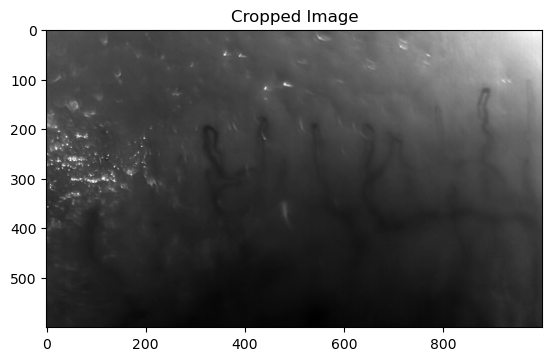

In [99]:
cropped_img_12 = image_12[1100:1700, 2000:3000] 
plt.imshow(cropped_img_12, cmap='gray')
plt.title("Cropped Image")
plt.show()

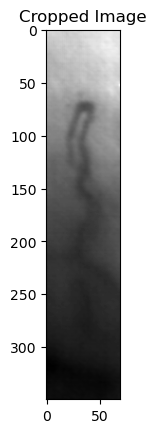

In [111]:
cropped_img_12 = image_12[1150:1500, 2850:2920] 
plt.imshow(cropped_img_12, cmap='gray')
plt.title("Cropped Image")
plt.show()

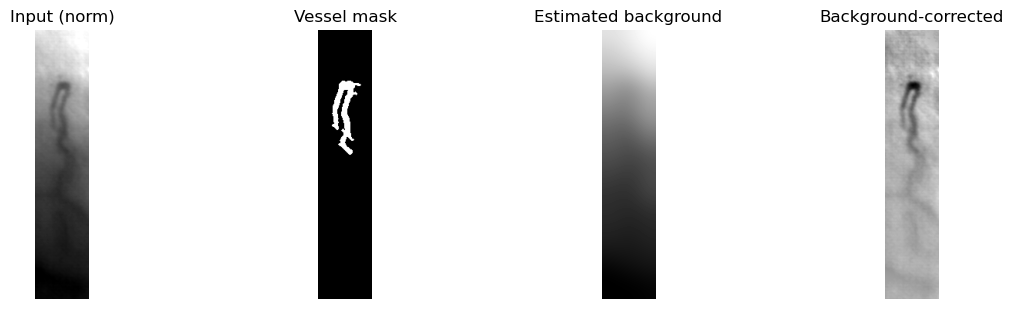

In [112]:
img_crop = cropped_img_12.astype(np.float32)
p1, p99 = np.percentile(img_crop, (1, 99))
img_n = np.clip((img_crop - p1) / (p99 - p1 + 1e-8), 0, 1)

# 1) Vessel mask (dark ridges)
sigmas = np.geomspace(1, 2, 2)  
resp = meijering(img_n, sigmas=sigmas, black_ridges=True)
resp = (resp - resp.min()) / (resp.max() - resp.min() + 1e-8)
BW = resp > threshold_otsu(resp)

# Cleanup & give some margin around vessels
BW = remove_small_objects(BW, min_size=100)
BW = remove_small_holes(BW, area_threshold=200)
BW = binary_dilation(BW, disk(1))          

# 2) Inpaint vessel regions
mask = BW.astype(bool)
img_inp = inpaint.inpaint_biharmonic(img_n, mask, channel_axis=None)

# 3) Low-pass the inpainted image to get background (use scale >> vessel width)
bg = gaussian_filter(img_inp, sigma=15)    

# 4) Background correction (keep range sane)
img_corr = np.clip(img_n - bg + bg.mean(), 0, 1)

fig, ax = plt.subplots(1,4, figsize=(14,3.5))
ax[0].imshow(img_n, cmap='gray'); ax[0].set_title('Input (norm)'); ax[0].axis('off')
ax[1].imshow(BW, cmap='gray');    ax[1].set_title('Vessel mask'); ax[1].axis('off')
ax[2].imshow(bg, cmap='gray');    ax[2].set_title('Estimated background'); ax[2].axis('off')
ax[3].imshow(img_corr, cmap='gray'); ax[3].set_title('Background-corrected'); ax[3].axis('off')
plt.show()

Sampling 30 lines from y=80 to y=100...
Sampling complete.

--- Analysis Results (Original 16-bit scale) ---
Background Min Intensity: 37956.216269
Background Mean Intensity: 39032.783772
Capillary Min Intensity: 33956.000000
Capillary Mean Intensity: 37737.582031

Saved mean profile stats to "intensity_profile_mean_PYTHON.csv"


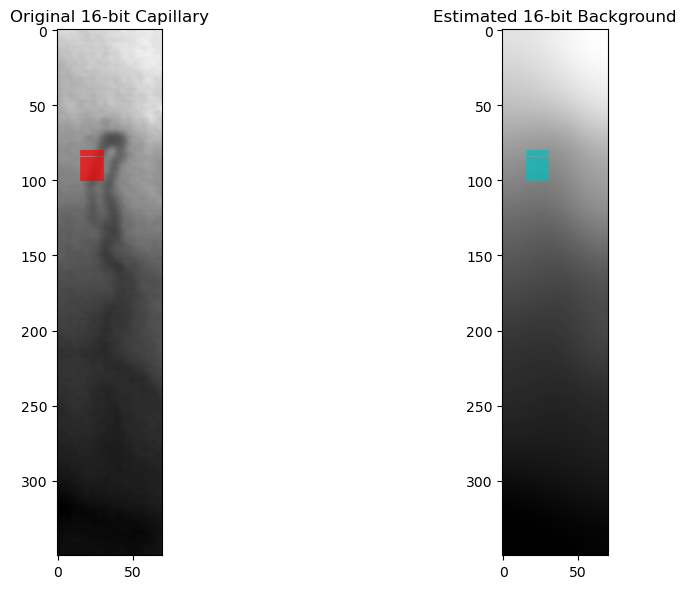

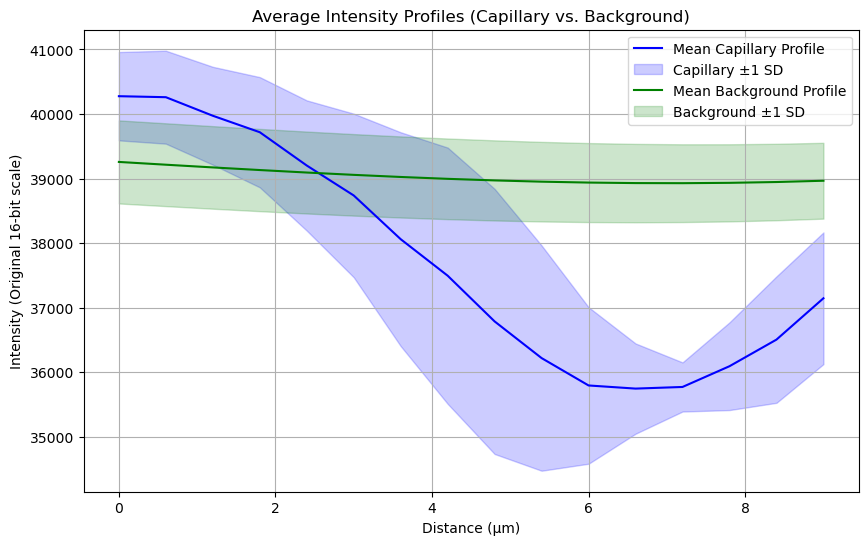

In [ ]:


from skimage.measure import profile_line
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Sampling Parameters (from your MATLAB script) ---
x_start = 15
x_end = 30
num_lines = 30
y_min = 80
y_max = 100

y_coords = np.linspace(y_min, y_max, num_lines)

bg_unnormalized = (bg * (p99 - p1 + 1e-8)) + p1

profiles_bg = []  # To store background profiles
profiles_cap = [] # To store capillary profiles

print(f"Sampling {num_lines} lines from y={y_min} to y={y_max}...")

for y in y_coords:
    # Define start and end points for the line
    start_point = (y, x_start) # (row, col)
    end_point = (y, x_end)   # (row, col)
    
    # Get profile from the UN-NORMALIZED background
    p_bg = profile_line(bg_unnormalized, start_point, end_point, mode='constant')
    profiles_bg.append(p_bg)
    
    # Get profile from the ORIGINAL 16-BIT capillary image ('img_crop')
    p_cap = profile_line(img_crop, start_point, end_point, mode='constant')
    profiles_cap.append(p_cap)

# Convert lists of profiles into 2D NumPy arrays
profiles_bg = np.array(profiles_bg)
profiles_cap = np.array(profiles_cap)

print("Sampling complete.")

# --- 3. Analyze the Profiles ---
# Both images are now on the SAME 16-bit unnormalized scale

# Background stats
min_intensity_bg = np.min(profiles_bg)
mean_intensity_bg = np.mean(profiles_bg)
mean_profile_bg = np.mean(profiles_bg, axis=0)
std_profile_bg = np.std(profiles_bg, axis=0)

# Capillary stats
min_intensity_cap = np.min(profiles_cap)
mean_intensity_cap = np.mean(profiles_cap)
mean_profile_cap = np.mean(profiles_cap, axis=0)
std_profile_cap = np.std(profiles_cap, axis=0)

# --- 4. Output and Save Results ---
print("\n--- Analysis Results (Original 16-bit scale) ---")
print(f"Background Min Intensity: {min_intensity_bg:.6f}")
print(f"Background Mean Intensity: {mean_intensity_bg:.6f}")
print(f"Capillary Min Intensity: {min_intensity_cap:.6f}")
print(f"Capillary Mean Intensity: {mean_intensity_cap:.6f}")

# --- 5. Create Distance Axis and Save to CSV (like MATLAB) ---
pix_um = 0.6  # Your pixel-to-micron scale
N = profiles_bg.shape[1] # Number of sample points in the profile
dist_px = np.arange(N)
dist_um = dist_px * pix_um

# Create a summary DataFrame
T_mean = pd.DataFrame({
    'Sample': np.arange(N),
    'Dist_px': dist_px,
    'Dist_um': dist_um,
    'MeanIntensity_Cap': mean_profile_cap,
    'StdIntensity_Cap': std_profile_cap,
    'MeanIntensity_Bg': mean_profile_bg,
    'StdIntensity_Bg': std_profile_bg
})

T_mean.to_csv('intensity_profile_mean_PYTHON.csv', index=False)
print(f'\nSaved mean profile stats to "intensity_profile_mean_PYTHON.csv"')

# --- 6. Plot the Images with Sampling Lines ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Original 16-bit Capillary Image
ax[0].imshow(img_crop, cmap='gray')
ax[0].set_title('Original 16-bit Capillary')
ax[0].axis('on')
# Draw the sampling lines
for y in y_coords:
    ax[0].plot([x_start, x_end], [y, y], 'r-', linewidth=0.5)

# Plot 2: Estimated 16-bit Background Image
ax[1].imshow(bg_unnormalized, cmap='gray')
ax[1].set_title('Estimated 16-bit Background')
ax[1].axis('on')
# Draw the sampling lines
for y in y_coords:
    ax[1].plot([x_start, x_end], [y, y], 'c-', linewidth=0.5)

plt.tight_layout()
plt.show()


# --- 7. Plot the Mean Profiles ---
plt.figure(figsize=(10, 6))
plt.grid(True)
plt.plot(dist_um, mean_profile_cap, 'b-', label='Mean Capillary Profile')
plt.fill_between(dist_um, mean_profile_cap - std_profile_cap, 
                 mean_profile_cap + std_profile_cap, 
                 color='blue', alpha=0.2, label='Capillary ±1 SD')

plt.plot(dist_um, mean_profile_bg, 'g-', label='Mean Background Profile')
plt.fill_between(dist_um, mean_profile_bg - std_profile_bg, 
                 mean_profile_bg + std_profile_bg, 
                 color='green', alpha=0.2, label='Background ±1 SD')

plt.xlabel('Distance (µm)')
plt.ylabel('Intensity (Original 16-bit scale)')
plt.title('Average Intensity Profiles (Capillary vs. Background)')
plt.legend()
plt.show()



## 12MP S2

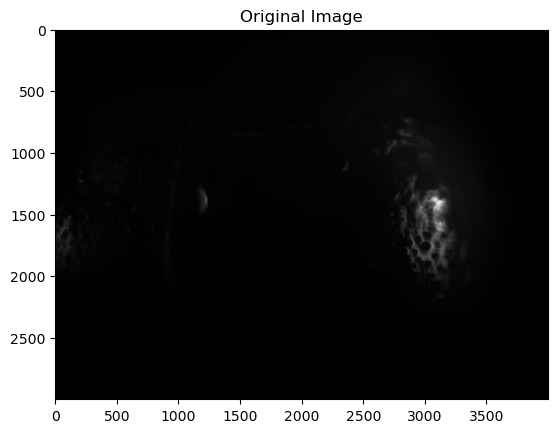

In [125]:
image_12_S2_2 = imread("../_images/10-31-2025/20251101_032124_1.tif")
plt.imshow(image_12_S2_2, cmap='gray')
plt.title("Original Image")
plt.show()

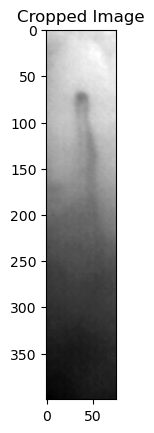

In [127]:
cropped_img_12_S2 = image_12_S2_2[1300:1700, 2025:2100] 
plt.imshow(cropped_img_12_S2, cmap='gray')
plt.title("Cropped Image")
plt.show()

## 12MP S1 (1/700)

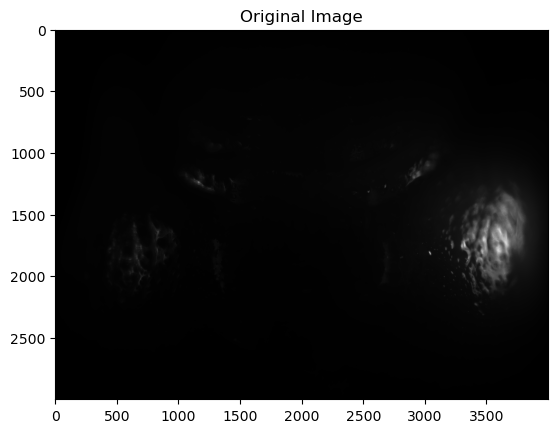

In [42]:
import imageio.v3 as iio
image_12_S1_700 = iio.imread("../_images/11042025_S1_F(1)_1-750_green_tiff/20251105_035806_green.tif")
plt.imshow(image_12_S1_700, cmap='gray')
plt.title("Original Image")
plt.show()

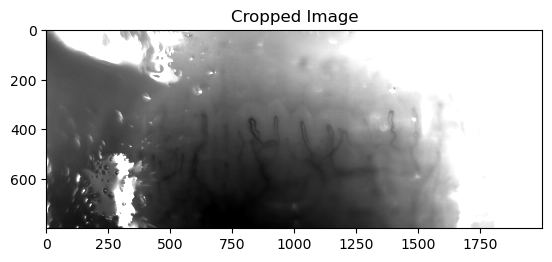

In [43]:
cropped_img_12 = image_12_S1_700[1200:2000, 1000:3000] 
plt.imshow(cropped_img_12, cmap='gray', vmin=90, vmax=350)
plt.title("Cropped Image")
plt.show()

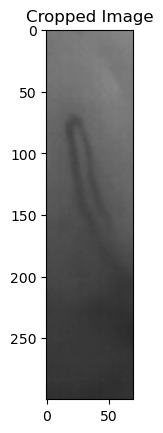

In [82]:
cropped_img_12 = image_12_S1_700[1500:1800, 2010:2080] 
plt.imshow(cropped_img_12, cmap='gray', vmin=80, vmax=350)
plt.title("Cropped Image")
plt.show()

## 12MP S2 (1/350)

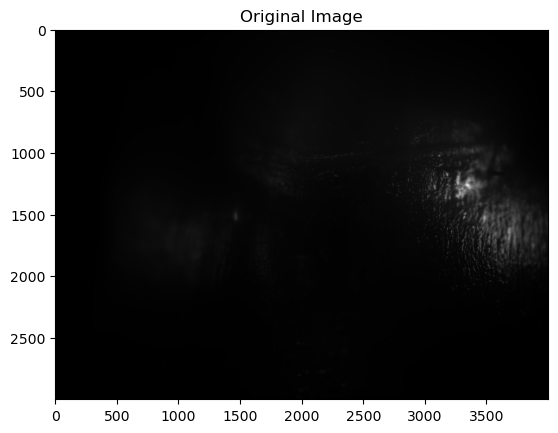

In [3]:
import imageio.v3 as iio
image_12_S2_350 = iio.imread("../_images/11042025_S2_F(3)_1-350_green_tiff/20251105_043403_green.tif")
plt.imshow(image_12_S2_350, cmap='gray')
plt.title("Original Image")
plt.show()

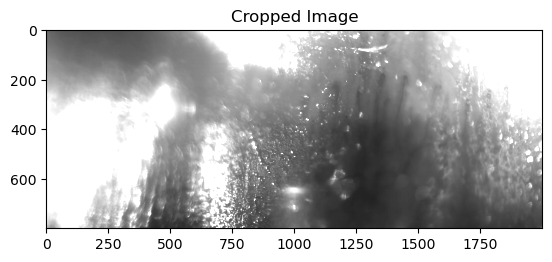

In [12]:
cropped_img_12_2 = image_12_S2_350[1200:2000, 1000:3000] 
plt.imshow(cropped_img_12_2, cmap='gray', vmin=100, vmax=600)
plt.title("Cropped Image")
plt.show()

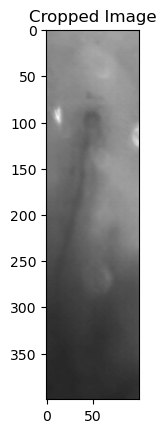

In [21]:
cropped_img_12_2 = image_12_S2_350[1300:1700, 2400:2500] 
plt.imshow(cropped_img_12_2, cmap='gray', vmin=150, vmax=600)
plt.title("Cropped Image")
plt.show()

Sampling 30 lines from y=110 to y=130...
Sampling complete.

Profile statistics calculated.

--- Analysis Results (Original 16-bit scale) ---
Background Min Intensity: 342.225464
Background Mean Intensity: 346.807800
Capillary Min Intensity: 309.310333
Capillary Mean Intensity: 332.714722

--- Plotting Intermediate Images ---


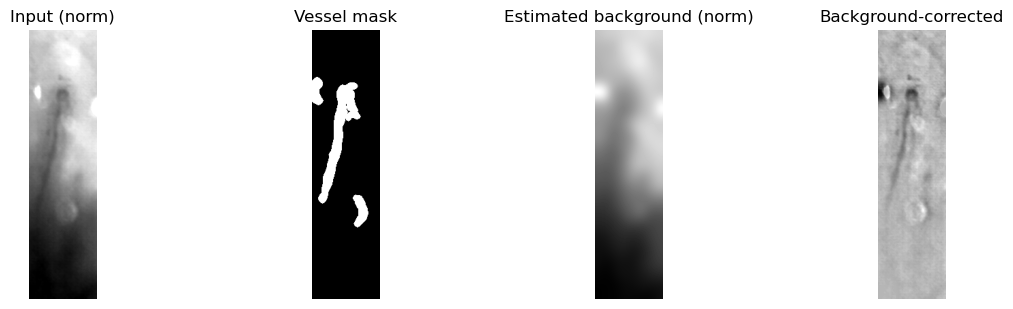

--- Plotting Image with Sampling Lines ---


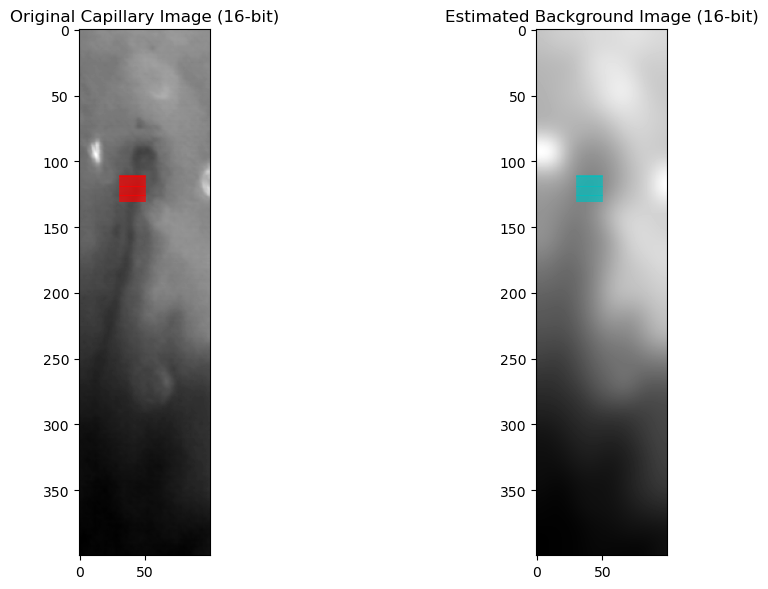

--- Plotting Mean Profiles ---


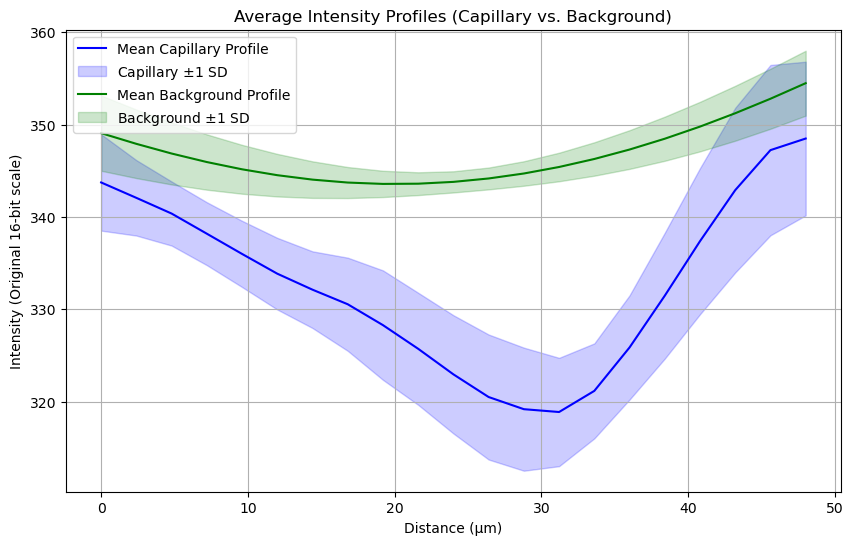

In [93]:
from skimage.morphology import remove_small_objects, remove_small_holes, binary_dilation, disk, binary_opening

def analyze_capillary_profiles(cropped_img_12, x_start, x_end, num_lines, y_min, y_max, pix_um=0.6, plot_results=True):
    """
    Performs image normalization, vessel masking, background estimation (using inpainting 
    and Gaussian filter), samples intensity profiles across a region in both the 
    original image and the estimated background, and plots/returns the results.
    ... [rest of docstring is unchanged] ...
    """
    
    img_crop = cropped_img_12.astype(np.float32)
    p1, p99 = np.percentile(img_crop, (1, 99))
    img_n = np.clip((img_crop - p1) / (p99 - p1 + 1e-8), 0, 1)

    sigmas = np.geomspace(2, 3, 2)  
    
    resp = meijering(img_n, sigmas=sigmas, black_ridges=True) # Use img_n directly
    resp = (resp - resp.min()) / (resp.max() - resp.min() + 1e-8)
    BW = resp > threshold_otsu(resp)

    # 2b. Cleanup & Final Dilation (Align disk(4) with target code)
    BW = remove_small_objects(BW, min_size=200)
    BW = remove_small_holes(BW, area_threshold=300)
    BW = binary_dilation(BW, disk(4)) 
    mask = BW.astype(bool)

    # --- 2c. Background Estimation Aligned with Target Code ---
    img_inp = inpaint.inpaint_biharmonic(img_crop, mask, channel_axis=None)
    bg_unnormalized = gaussian_filter(img_inp, sigma=8)
    
    # --- 2d. Prepare for Correction and Profiling ---
    bg = np.clip((bg_unnormalized - p1) / (p99 - p1 + 1e-8), 0, 1)

    # 2e. Background correction (not strictly needed for profiling, but good practice)
    img_corr = np.clip(img_n - bg + bg.mean(), 0, 1)

    # --- 4. Define Sampling Coordinates ---
    y_coords = np.linspace(y_min, y_max, num_lines)
    
    profiles_bg = []  # To store background profiles
    profiles_cap = [] # To store capillary profiles

    print(f"Sampling {num_lines} lines from y={y_min} to y={y_max}...")

    for y in y_coords:
        # Define start and end points for the line (row, col)
        start_point = (y, x_start) 
        end_point = (y, x_end)   

        p_bg = profile_line(bg_unnormalized, start_point, end_point, mode='constant')
        profiles_bg.append(p_bg)
        
        p_cap = profile_line(img_crop, start_point, end_point, mode='constant')
        profiles_cap.append(p_cap)

    profiles_bg = np.array(profiles_bg)
    profiles_cap = np.array(profiles_cap)
    print("Sampling complete.")

    # --- 5. Analyze the Profiles ---
    
    mean_profile_cap = np.mean(profiles_cap, axis=0)
    std_profile_cap = np.std(profiles_cap, axis=0)
    mean_profile_bg = np.mean(profiles_bg, axis=0)
    std_profile_bg = np.std(profiles_bg, axis=0)

    # --- 6. Create Distance Axis and Summary DataFrame ---
    N = profiles_bg.shape[1] # Number of sample points in the profile
    dist_px = np.arange(N)
    dist_um = dist_px * pix_um

    T_mean = pd.DataFrame({
        'Sample': np.arange(N),
        'Dist_px': dist_px,
        'Dist_um': dist_um,
        'MeanIntensity_Cap': mean_profile_cap,
        'StdIntensity_Cap': std_profile_cap,
        'MeanIntensity_Bg': mean_profile_bg,
        'StdIntensity_Bg': std_profile_bg
    })
    
    print(f'\nProfile statistics calculated.')

    mean_profile_cap = np.mean(profiles_cap, axis=0)
    std_profile_cap = np.std(profiles_cap, axis=0)
    mean_profile_bg = np.mean(profiles_bg, axis=0)
    std_profile_bg = np.std(profiles_bg, axis=0)
    
    # Calculate MINIMUMs across all sampled lines
    min_intensity_bg = np.min(profiles_bg)
    min_intensity_cap = np.min(profiles_cap)
    
    print("\n--- Analysis Results (Original 16-bit scale) ---")
    print(f"Background Min Intensity: {min_intensity_bg:.6f}")
    print(f"Background Mean Intensity: {np.mean(profiles_bg):.6f}")
    print(f"Capillary Min Intensity: {min_intensity_cap:.6f}")
    print(f"Capillary Mean Intensity: {np.mean(profiles_cap):.6f}")
    
    # --- 7. Plot Results (Optional) ---
    if plot_results:
        print("\n--- Plotting Intermediate Images ---")
        fig1, ax1 = plt.subplots(1,4, figsize=(14,3.5))
        ax1[0].imshow(img_n, cmap='gray'); ax1[0].set_title('Input (norm)'); ax1[0].axis('off')
        ax1[1].imshow(BW, cmap='gray');    ax1[1].set_title('Vessel mask'); ax1[1].axis('off')
        ax1[2].imshow(bg_unnormalized, cmap='gray');    ax1[2].set_title('Estimated background (norm)'); ax1[2].axis('off')
        ax1[3].imshow(img_corr, cmap='gray'); ax1[3].set_title('Background-corrected'); ax1[3].axis('off')
        plt.show()

        print("--- Plotting Image with Sampling Lines ---")
        fig2, ax2 = plt.subplots(1, 2, figsize=(12, 6))

        # Plot 1: Original 16-bit Capillary Image
        ax2[0].imshow(img_crop, cmap='gray')
        ax2[0].set_title('Original Capillary Image (16-bit)')
        ax2[0].axis('on')
        # Draw the sampling lines
        for y in y_coords:
            ax2[0].plot([x_start, x_end], [y, y], 'r-', linewidth=0.5)

        # Plot 2: Estimated 16-bit Background Image
        ax2[1].imshow(bg_unnormalized, cmap='gray')
        ax2[1].set_title('Estimated Background Image (16-bit)')
        ax2[1].axis('on')
        # Draw the sampling lines
        for y in y_coords:
            ax2[1].plot([x_start, x_end], [y, y], 'c-', linewidth=0.5)

        plt.tight_layout()
        plt.show()

        print("--- Plotting Mean Profiles ---")
        fig3, ax3 = plt.subplots(figsize=(10, 6))
        ax3.grid(True)
        ax3.plot(dist_um, mean_profile_cap, 'b-', label='Mean Capillary Profile')
        ax3.fill_between(dist_um, mean_profile_cap - std_profile_cap, 
                         mean_profile_cap + std_profile_cap, 
                         color='blue', alpha=0.2, label='Capillary $\\pm 1$ SD')

        ax3.plot(dist_um, mean_profile_bg, 'g-', label='Mean Background Profile')
        ax3.fill_between(dist_um, mean_profile_bg - std_profile_bg, 
                         mean_profile_bg + std_profile_bg, 
                         color='green', alpha=0.2, label='Background $\\pm 1$ SD')

        ax3.set_xlabel('Distance (µm)')
        ax3.set_ylabel('Intensity (Original 16-bit scale)')
        ax3.set_title('Average Intensity Profiles (Capillary vs. Background)')
        ax3.legend()
        plt.show()
        
    return T_mean

x_start_param = 30
x_end_param = 50
num_lines_param = 30
y_min_param = 110
y_max_param = 130
pixel_to_um_scale = 2.4

mean_profiles_df = analyze_capillary_profiles(
    cropped_img_12_2, 
    x_start_param, 
    x_end_param, 
    num_lines_param, 
    y_min_param, 
    y_max_param, 
    pix_um=pixel_to_um_scale, 
    plot_results=True
)